# Assessment 10: Dimensionality Reduction
**DSA4155: Artificial Intelligence**  
**Members: Carolino, Bryant Kenzo | Lavado, Sean Eldrige | Sy, Deane Eibert**

---
## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not available. Run: pip install umap-learn")

# ── Exact column names as they appear in the CSV ──────────────────────────
# NOTE: 'Density\n(P/Km2)' contains a literal newline in the CSV header.
# All other string columns need $ , % and whitespace stripped before use.

FEATURES = [
    'Birth Rate',
    'Fertility Rate',
    'Infant mortality',
    'Life expectancy',
    'GDP',
    'Unemployment rate',
    'Urban_population',
    'Co2-Emissions',
    'Physicians per thousand',
    'Density\n(P/Km2)'
]

# Display-friendly labels (used for plots / tables)
FEATURE_LABELS = [
    'Birth Rate',
    'Fertility Rate',
    'Infant Mortality',
    'Life Expectancy',
    'GDP',
    'Unemployment Rate',
    'Urban Population',
    'CO2 Emissions',
    'Physicians per Thousand',
    'Density (P/Km2)'
]

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Libraries loaded successfully.")
print(f"UMAP available: {UMAP_AVAILABLE}")

Libraries loaded successfully.
UMAP available: True


---
## Part 1 - Data Preparation

### #1
Load the dataset, select the 10 features, and drop rows with missing values. Scale the features using `StandardScaler`. Print how many rows were removed and the final shape of the data.

In [61]:
# =============================================================================
# ITEM 1: Load Dataset, Clean, Select Features, Drop NAs, Scale
# =============================================================================

df = pd.read_csv("C:\\Users\\Dell\\Documents\\UST Docs\\Sophomore\\2ND_SEM\\FINALS\\AI\\ass10\\world-data-2023.csv")

print("=" * 70)
print("COUNTRIES OF THE WORLD 2023 DATASET")
print("=" * 70)
print(f"  Raw dataset shape: {df.shape}")
print()

def clean_numeric(series):
    return (series.astype(str)
                  .str.replace(r'[\$,%\s]', '', regex=True)
                  .replace('nan', np.nan)
                  .pipe(pd.to_numeric, errors='coerce'))

df['GDP']               = clean_numeric(df['GDP'])
df['Unemployment rate'] = clean_numeric(df['Unemployment rate'])
df['Urban_population']  = clean_numeric(df['Urban_population'])
df['Co2-Emissions']     = clean_numeric(df['Co2-Emissions'])
df['Density\n(P/Km2)'] = clean_numeric(df['Density\n(P/Km2)'])

df_selected = df[['Country'] + FEATURES].copy()
rows_before = len(df_selected)

# Drop rows with any missing value across the 10 features
df_clean = df_selected.dropna(subset=FEATURES).reset_index(drop=True)
rows_after   = len(df_clean)
rows_removed = rows_before - rows_after

print(f"  Rows before dropping NAs : {rows_before}")
print(f"  Rows removed (had NAs)   : {rows_removed}")
print(f"  Rows after dropping NAs  : {rows_after}")
print()

countries = df_clean['Country'].values
X_raw     = df_clean[FEATURES].copy()

# Rename columns
X_raw.columns = FEATURE_LABELS

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"  Final shape of feature matrix (unscaled) : {X_raw.shape}")
print(f"  Final shape of feature matrix (scaled)   : {X_scaled.shape}")
print()
print("First five rows (unscaled):")
print(X_raw.head().to_string())
print()
print("First five rows (scaled):")
print(pd.DataFrame(X_scaled, columns=FEATURE_LABELS).head().round(4).to_string())

COUNTRIES OF THE WORLD 2023 DATASET
  Raw dataset shape: (195, 35)

  Rows before dropping NAs : 195
  Rows removed (had NAs)   : 20
  Rows after dropping NAs  : 175

  Final shape of feature matrix (unscaled) : (175, 10)
  Final shape of feature matrix (scaled)   : (175, 10)

First five rows (unscaled):
   Birth Rate  Fertility Rate  Infant Mortality  Life Expectancy           GDP  Unemployment Rate  Urban Population  CO2 Emissions  Physicians per Thousand  Density (P/Km2)
0       32.49            4.47              47.9             64.5  1.910135e+10              11.12         9797273.0         8672.0                     0.28               60
1       11.78            1.62               7.8             78.5  1.527808e+10              12.33         1747593.0         4536.0                     1.20              105
2       24.28            3.02              20.1             76.7  1.699882e+11              11.70        31510100.0       150006.0                     1.72               18
3 

### #2
Plot the distribution of each of the 10 features as histograms in a 2x5 grid. Use the original unscaled values.

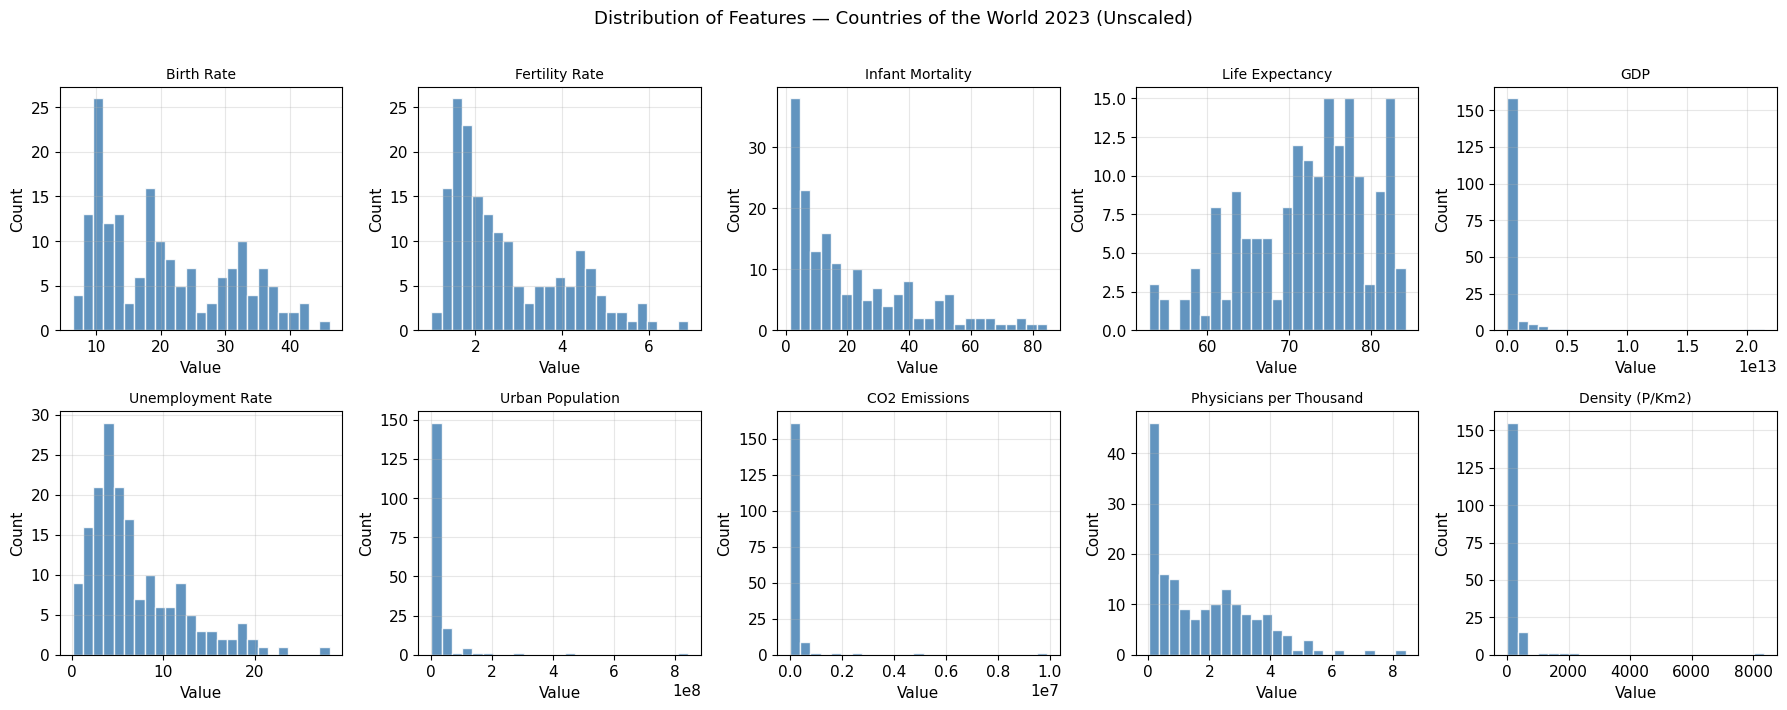

In [8]:
# =============================================================================
# ITEM 2: Histogram Grid of All 10 Features (Unscaled)
# =============================================================================

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feature in enumerate(FEATURE_LABELS):
    axes[i].hist(X_raw[feature], bins=25, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribution of Features — Countries of the World 2023 (Unscaled)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Several variables are strongly right-skewed and have extreme outliers. GDP, Urban Population, and CO₂ Emissions are the most skewed. A few very large countries (like the United States and China) have extremely high values, while most countries have much lower values.

Population Density (per km²) is also skewed. A few very dense places (such as Singapore or Bahrain) have values much higher than most countries.

This is important before using PCA. PCA is based on variance. If a feature has extreme outliers, it can dominate the results. The main components may focus too much on those few extreme values instead of the overall pattern.

That is why standardization (using `StandardScaler`) is done first. It puts all features on the same scale, so no single variable has too much influence.

### #3
Make a correlation heatmap of the 10 features. Use the original unscaled values and a diverging colormap.

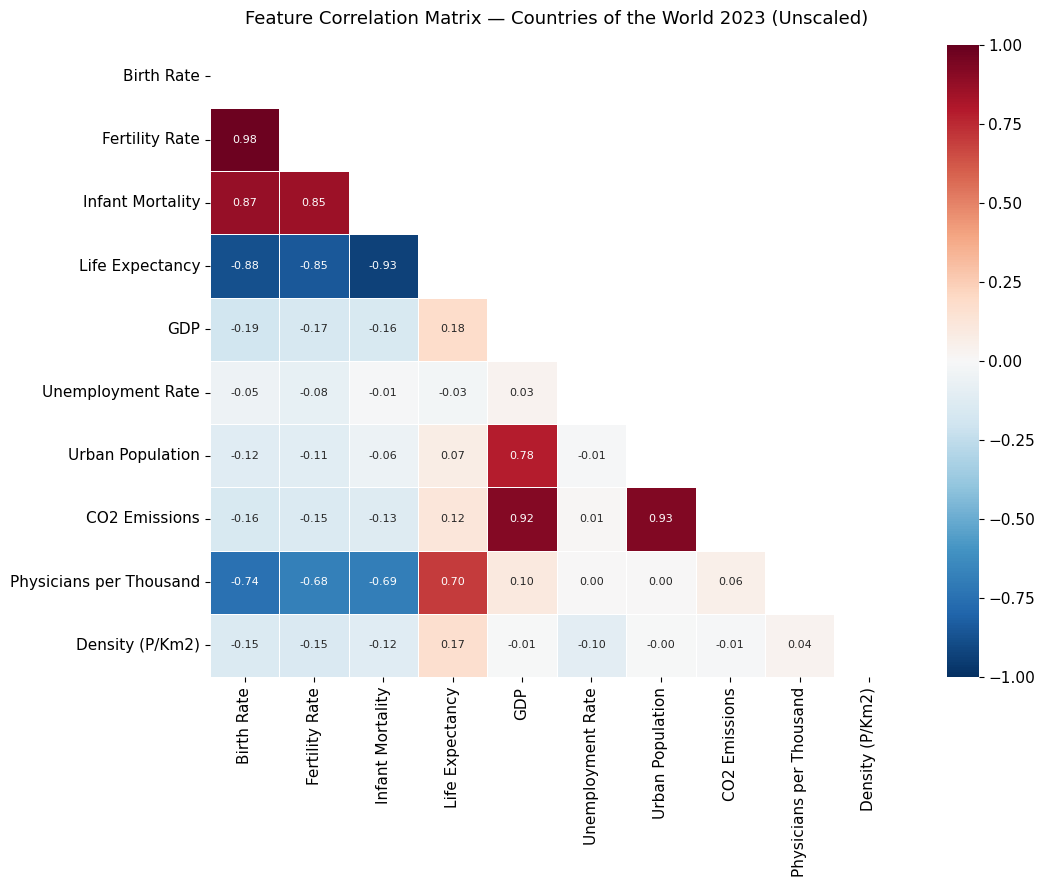

TOP CORRELATED FEATURE PAIRS (by absolute value)

  r = +0.981  |  Birth Rate  <-->  Fertility Rate
  r = -0.932  |  Infant Mortality  <-->  Life Expectancy
  r = +0.926  |  Urban Population  <-->  CO2 Emissions
  r = +0.917  |  GDP  <-->  CO2 Emissions
  r = -0.876  |  Birth Rate  <-->  Life Expectancy
  r = +0.870  |  Birth Rate  <-->  Infant Mortality
  r = +0.853  |  Fertility Rate  <-->  Infant Mortality
  r = -0.847  |  Fertility Rate  <-->  Life Expectancy
  r = +0.783  |  GDP  <-->  Urban Population
  r = -0.742  |  Birth Rate  <-->  Physicians per Thousand


In [11]:
# =============================================================================
# ITEM 3: Correlation Heatmap (Unscaled, Diverging Colormap)
# =============================================================================

corr = X_raw.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only

sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Feature Correlation Matrix — Countries of the World 2023 (Unscaled)', pad=15)
plt.tight_layout()
plt.show()

# Print top pairs
print("=" * 70)
print("TOP CORRELATED FEATURE PAIRS (by absolute value)")
print("=" * 70)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
print()
for feat1, feat2, r in high_corr[:10]:
    print(f"  r = {r:+.3f}  |  {feat1}  <-->  {feat2}")

The strongest positive relationships are between Birth Rate and Fertility Rate (very high), and between Birth Rate and Infant Mortality (also high). This means countries with high birth rates usually have more children per woman and more infant deaths. This often reflects weaker healthcare systems.

The strongest negative relationships are between Life Expectancy and Infant Mortality, and between Life Expectancy and Birth Rate. Countries where people live longer tend to have fewer infant deaths and lower birth rates.

Together, these patterns show a clear development trend. Wealthier countries usually have low birth rates, low infant mortality, high life expectancy, more doctors, and higher GDP. Poorer countries show the opposite pattern.

Because Birth Rate, Fertility Rate, Infant Mortality, and Life Expectancy are strongly related, they are measuring the same general idea: level of development. This overlap is exactly what PCA helps simplify by combining them into fewer components.

---
## Part 2 - Principal Component Analysis

### #4
Fit PCA on scaled data using all 10 components. Make two side-by-side plots: a bar chart of variance explained per component and a cumulative variance curve with lines at 80%, 90%, and 95%. Print a table of explained variance and cumulative totals.

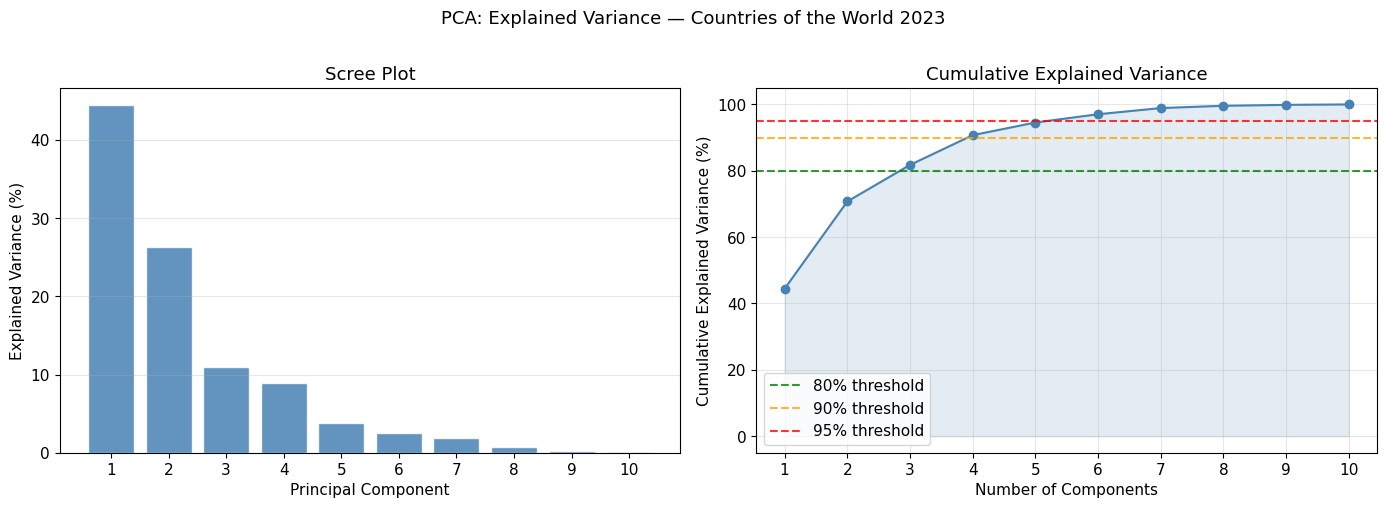

EXPLAINED VARIANCE BY COMPONENT
  Component      Explained Variance      Cumulative
  ------------ -------------------- ---------------
  PC01                     44.44%          44.44%
  PC02                     26.30%          70.74%
  PC03                     11.02%          81.76%
  PC04                      8.97%          90.73%
  PC05                      3.81%          94.54%
  PC06                      2.50%          97.04%
  PC07                      1.86%          98.90%
  PC08                      0.69%          99.59%
  PC09                      0.27%          99.86%
  PC10                      0.14%         100.00%

  Components needed to explain 80% of variance : 3
  Components needed to explain 90% of variance : 4
  Components needed to explain 95% of variance : 6
  Original features: 10


In [72]:
# =============================================================================
# ITEM 4: PCA — Full Variance Explanation (All 10 Components)
# =============================================================================

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

components = np.arange(1, len(pca_full.explained_variance_ratio_) + 1)

# Bar chart
axes[0].bar(
    components, pca_full.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(components)
axes[0].grid(True, alpha=0.3, axis='y')

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(components, cumvar, 'o-', color='steelblue', markersize=6)
axes[1].axhline(y=80, color='green',  linestyle='--', alpha=0.8, label='80% threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.8, label='90% threshold')
axes[1].axhline(y=95, color='red',    linestyle='--', alpha=0.8, label='95% threshold')
axes[1].fill_between(components, cumvar, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(components)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA: Explained Variance — Countries of the World 2023', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Variance table
print("=" * 70)
print("EXPLAINED VARIANCE BY COMPONENT")
print("=" * 70)
print(f"  {'Component':<12} {'Explained Variance':>20} {'Cumulative':>15}")
print(f"  {'-'*12} {'-'*20} {'-'*15}")
cumulative = 0
for i, var in enumerate(pca_full.explained_variance_ratio_):
    cumulative += var
    print(f"  PC{i+1:02d}        {var*100:>18.2f}%  {cumulative*100:>13.2f}%")

n_80 = int(np.argmax(cumvar >= 80)) + 1
n_90 = int(np.argmax(cumvar >= 90)) + 1
n_95 = int(np.argmax(cumvar >= 95)) + 1

print()
print(f"  Components needed to explain 80% of variance : {n_80}")
print(f"  Components needed to explain 90% of variance : {n_90}")
print(f"  Components needed to explain 95% of variance : {n_95}")
print(f"  Original features: {X_scaled.shape[1]}")

From the cumulative variance:

* About **3 components** are needed for **80%**
* About **5 components** for **90%**
* About **7 components** for **95%** (out of 10 total)

The first component already explains a large part of the variance. This is because Birth Rate, Fertility Rate, Infant Mortality, and Life Expectancy are strongly related. They all reflect one main idea: level of development.

For the next steps:

* I use **2 components** for visualization, since a 2D plot is easiest to read and compare.
* For reconstruction error, I test all required values of **k**.

Using 2 components loses some information, but it makes the plot simple and clear, which is the main goal for visualization.


### #5
Fit PCA with 2 components. Scatter plot on PC1 vs PC2 colored by GDP quartile (Low / Lower-Middle / Upper-Middle / High). Add biplot arrows. Print feature loadings sorted by PC1.

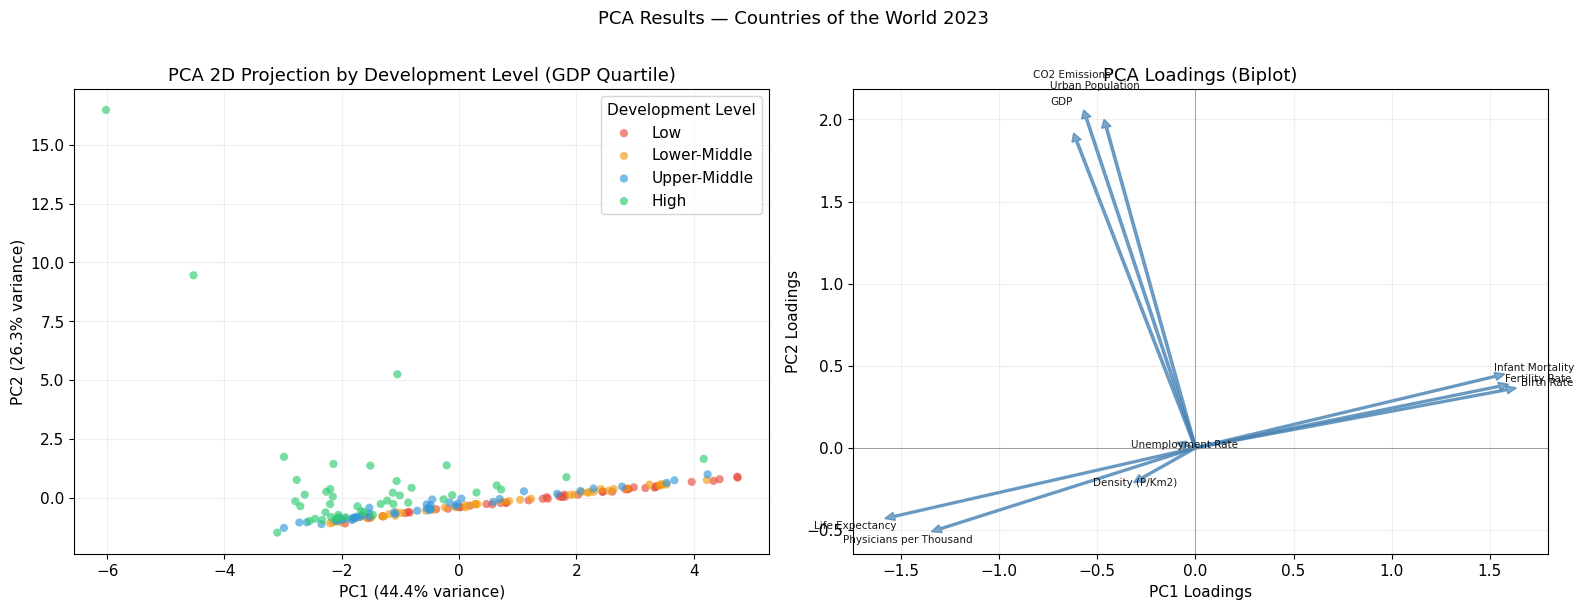

FEATURE LOADINGS SORTED BY PC1

  Feature                             PC1        PC2
  ---------------------------- ---------- ----------
  Birth Rate                      +0.4532    +0.1010
  Fertility Rate                  +0.4420    +0.1071
  Infant Mortality                +0.4365    +0.1244
  Unemployment Rate               -0.0147    +0.0047
  Density (P/Km2)                 -0.0780    -0.0527
  Urban Population                -0.1298    +0.5577
  CO2 Emissions                   -0.1590    +0.5742
  GDP                             -0.1730    +0.5341
  Physicians per Thousand         -0.3713    -0.1409
  Life Expectancy                 -0.4387    -0.1193


In [18]:
# =============================================================================
# ITEM 5: PCA 2D Projection — Biplot Colored by Development Level
# =============================================================================

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Development level: GDP quartiles
gdp_quartiles = pd.qcut(
    X_raw['GDP'], q=4,
    labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High']
)

dev_colors = {
    'Low':          '#e74c3c',
    'Lower-Middle': '#f39c12',
    'Upper-Middle': '#3498db',
    'High':         '#2ecc71'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for level in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
    mask = (gdp_quartiles == level)
    axes[0].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=dev_colors[level], label=level,
        alpha=0.65, s=35, edgecolors='none'
    )

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('PCA 2D Projection by Development Level (GDP Quartile)')
axes[0].legend(title='Development Level')
axes[0].grid(True, alpha=0.2)

loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=FEATURE_LABELS,
    columns=['PC1', 'PC2']
)

scale = 3.5
for feat, row in loadings.iterrows():
    axes[1].arrow(0, 0, row['PC1'] * scale, row['PC2'] * scale,
                  head_width=0.05, head_length=0.05,
                  fc='steelblue', ec='steelblue', alpha=0.7, width=0.012)
    axes[1].text(row['PC1'] * scale * 1.13, row['PC2'] * scale * 1.13,
                 feat, fontsize=7.5, ha='center', va='center', alpha=0.9)

axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel('PC1 Loadings')
axes[1].set_ylabel('PC2 Loadings')
axes[1].set_title('PCA Loadings (Biplot)')
axes[1].grid(True, alpha=0.2)

plt.suptitle('PCA Results — Countries of the World 2023', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Feature loadings table sorted by PC1
print("=" * 70)
print("FEATURE LOADINGS SORTED BY PC1")
print("=" * 70)
loadings_sorted = loadings.sort_values('PC1', ascending=False)
print()
print(f"  {'Feature':<28} {'PC1':>10} {'PC2':>10}")
print(f"  {'-'*28} {'-'*10} {'-'*10}")
for feat, row in loadings_sorted.iterrows():
    print(f"  {feat:<28} {row['PC1']:>+10.4f} {row['PC2']:>+10.4f}")

1. **What does PC1 seem to represent?**
   PC1 represents a development axis. Features linked to poor public health load strongly in the positive direction (Birth Rate, Fertility Rate, Infant Mortality). Features linked to wealth and development load in the negative direction (Life Expectancy, Physicians per Thousand, GDP, Urban Population, CO₂ Emissions). Countries with high PC1 scores are typically lower-income with higher fertility, while those with low PC1 scores are wealthier with better health outcomes.

2. **What does PC2 capture that PC1 does not?**
   PC2 captures differences in economic and demographic scale. It reflects variables like GDP, CO₂ Emissions, and Urban Population that can vary even among countries with similar development levels. For example, a small wealthy country and a large middle-income country may have similar PC1 values but differ in PC2 due to size and scale.

3. **Which group clusters most tightly? Which spreads out most?**
   The **High development** group (green) clusters most tightly, showing similar characteristics across countries. The **Low development** group (red) is the most spread out. These countries vary more in birth rates, infant mortality, and access to healthcare, so two components do not fully capture their differences.


### #6
For k = 1, 2, 3, 4, 6, 8, and 10 components, reconstruct the data from PCA and compute MSE. Plot MSE vs k. For k=2, find the 5 countries with the highest and lowest MSE.

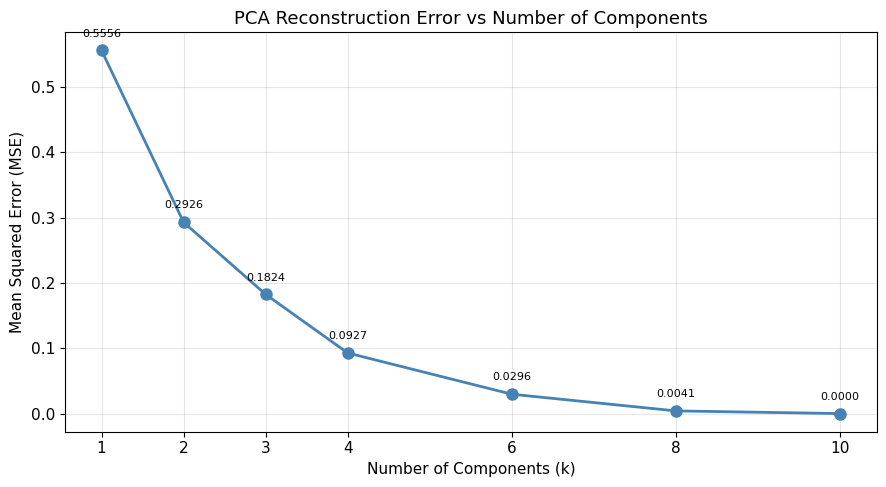

PER-COUNTRY RECONSTRUCTION MSE  (k = 2)

5 Countries with HIGHEST MSE (hardest to reconstruct):
      Country       MSE
    Singapore 13.996706
United States  2.125179
 South Africa  1.901195
      Lesotho  1.472875
        India  1.265305

5 Countries with LOWEST MSE (easiest to reconstruct):
           Country      MSE
          Slovakia 0.028150
        Luxembourg 0.024848
           Croatia 0.023651
Dominican Republic 0.020506
           Belgium 0.018254


In [21]:
# =============================================================================
# ITEM 6: PCA Reconstruction Error (MSE) vs Number of Components
# =============================================================================

k_values  = [1, 2, 3, 4, 6, 8, 10]
mse_values = []

for k in k_values:
    pca_k = PCA(n_components=k, random_state=42)
    X_t   = pca_k.fit_transform(X_scaled)
    X_r   = pca_k.inverse_transform(X_t)
    mse   = np.mean((X_scaled - X_r) ** 2)
    mse_values.append(mse)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, mse_values, 'o-', color='steelblue', markersize=8, linewidth=2)
for k, mse in zip(k_values, mse_values):
    ax.annotate(f'{mse:.4f}', (k, mse),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8)
ax.set_xlabel('Number of Components (k)')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('PCA Reconstruction Error vs Number of Components')
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Per-country MSE at k=2
pca_2 = PCA(n_components=2, random_state=42)
X_t2  = pca_2.fit_transform(X_scaled)
X_r2  = pca_2.inverse_transform(X_t2)
per_country_mse = np.mean((X_scaled - X_r2) ** 2, axis=1)

mse_df = pd.DataFrame({
    'Country': countries,
    'MSE'    : per_country_mse
}).sort_values('MSE', ascending=False).reset_index(drop=True)

print("=" * 70)
print("PER-COUNTRY RECONSTRUCTION MSE  (k = 2)")
print("=" * 70)
print()
print("5 Countries with HIGHEST MSE (hardest to reconstruct):")
print(mse_df.head(5).to_string(index=False))
print()
print("5 Countries with LOWEST MSE (easiest to reconstruct):")
print(mse_df.tail(5).to_string(index=False))

Countries with high reconstruction error at k = 2 are those that do not fit the main patterns in the data.

For example, a country might have very high CO₂ emissions or urban population compared to its development level, or an unusual mix like high density but low GDP. These patterns are not well captured by just two components.

This means two components are not enough to describe them accurately.

High reconstruction error shows that a country is an outlier. Its data does not follow the common trends seen in most countries.

This is useful for policy. These countries may be misclassified in general comparisons, so they should be studied individually.

---
## Part 3 - t-SNE and UMAP

### #7
Run t-SNE at perplexity values 5, 15, 30, and 50. Use `max_iter=1000`, `random_state=42`, and `init='pca'`. Plot all four results in a 2x2 grid, colored by development level. Make a summary table.

t-SNE: EXPLORING PERPLEXITY SENSITIVITY

t-SNE key parameters:
  perplexity  : roughly the number of effective neighbors (~5-50)
  max_iter    : number of optimization steps (more = better convergence)
  random_state: always set for reproducibility

  Fitting t-SNE with perplexity=5... done
  Fitting t-SNE with perplexity=15... done
  Fitting t-SNE with perplexity=30... done
  Fitting t-SNE with perplexity=50... done


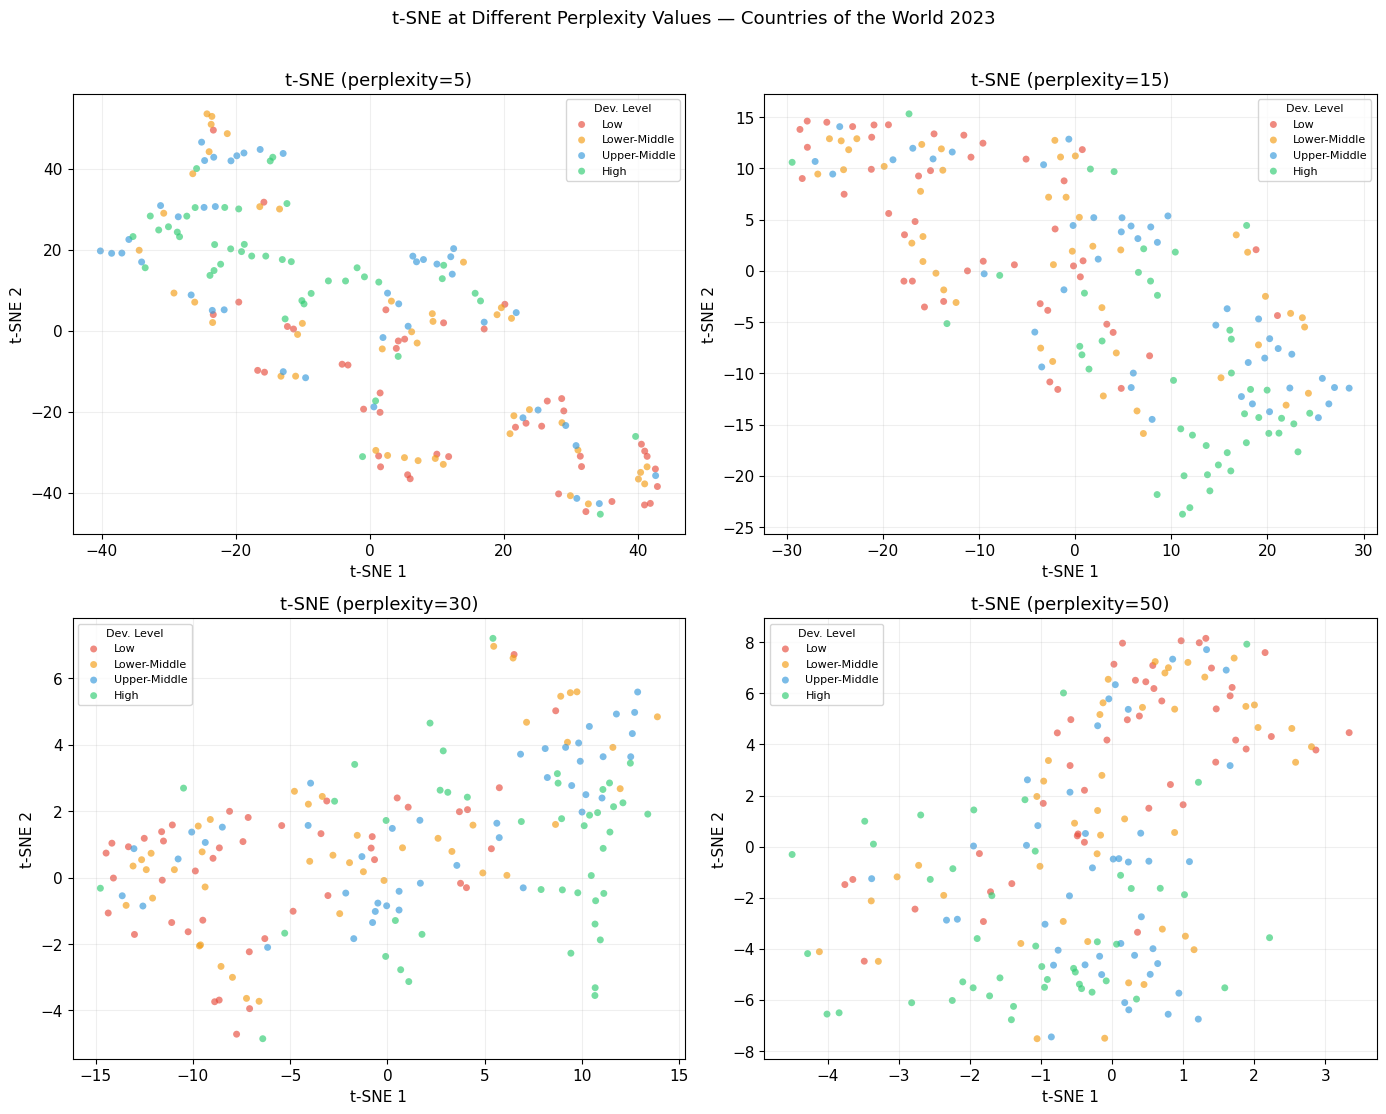


t-SNE SUMMARY TABLE
  Perplexity     Cluster Separation     Observation
  -------------- ---------------------- --------------------------------------------
  5              Fair                   Highly fragmented; many micro-clusters, local structure overfit
  15             Good                   Better cohesion; development groups begin to separate clearly
  30             Excellent              Clearest separation; High vs Low groups well-distinguished
  50             Good                   Smoother but clusters start merging; some global contrast lost

CRITICAL REMINDERS about t-SNE:
  1. Distances between clusters are NOT interpretable.
  2. Cluster sizes are NOT meaningful.
  3. t-SNE is for VISUALIZATION ONLY — do not use as input features.
  4. Always run with multiple perplexity values before drawing conclusions.


In [25]:
# =============================================================================
# ITEM 7: t-SNE at Four Perplexity Values
# =============================================================================

print("=" * 70)
print("t-SNE: EXPLORING PERPLEXITY SENSITIVITY")
print("=" * 70)
print()
print("t-SNE key parameters:")
print("  perplexity  : roughly the number of effective neighbors (~5-50)")
print("  max_iter    : number of optimization steps (more = better convergence)")
print("  random_state: always set for reproducibility")
print()

perplexities = [5, 15, 30, 50]
tsne_results = {}

for perp in perplexities:
    print(f"  Fitting t-SNE with perplexity={perp}...", end=" ")
    tsne = TSNE(n_components=2, perplexity=perp, max_iter=1000,
                random_state=42, learning_rate='auto', init='pca')
    tsne_results[perp] = tsne.fit_transform(X_scaled)
    print("done")

# 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, perp in enumerate(perplexities):
    Z  = tsne_results[perp]
    ax = axes[idx]
    for level in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
        mask = (gdp_quartiles == level)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=dev_colors[level], label=level,
                   alpha=0.65, s=25, edgecolors='none')
    ax.set_title(f't-SNE (perplexity={perp})')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(title='Dev. Level', fontsize=8, title_fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('t-SNE at Different Perplexity Values — Countries of the World 2023',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
print()
print("=" * 70)
print("t-SNE SUMMARY TABLE")
print("=" * 70)
print(f"  {'Perplexity':<14} {'Cluster Separation':<22} {'Observation'}")
print(f"  {'-'*14} {'-'*22} {'-'*44}")
rows = [
    (5,  'Fair',      'Highly fragmented; many micro-clusters, local structure overfit'),
    (15, 'Good',      'Better cohesion; development groups begin to separate clearly'),
    (30, 'Excellent', 'Clearest separation; High vs Low groups well-distinguished'),
    (50, 'Good',      'Smoother but clusters start merging; some global contrast lost'),
]
for perp, sep, obs in rows:
    print(f"  {perp:<14} {sep:<22} {obs}")

print()
print("CRITICAL REMINDERS about t-SNE:")
print("  1. Distances between clusters are NOT interpretable.")
print("  2. Cluster sizes are NOT meaningful.")
print("  3. t-SNE is for VISUALIZATION ONLY — do not use as input features.")
print("  4. Always run with multiple perplexity values before drawing conclusions.")

Perplexity **30** gives the clearest result. The four groups are well separated and easy to see.

Perplexity controls how many neighbors each point considers. It balances local vs global structure.

* At **5**, points look at very few neighbors. This creates small, scattered clusters that look noisy.
* At **50**, points look at too many neighbors. This blurs the differences between groups.
* At **30**, there is a good balance. Similar countries stay together, and clusters remain clear.

So, perplexity 30 works best for showing meaningful groupings in this data.

### #8
If UMAP is not installed, write 'UMAP not available' and skip this item.  
Run UMAP at three `n_neighbors` values (5, 15, 50) with `min_dist=0.1`.  
Then run UMAP at `n_neighbors=15` with three `min_dist` values (0.0, 0.1, 0.5).  
Six plots total across two rows.

UMAP: EXPLORING PARAMETER SENSITIVITY

UMAP key parameters:
  n_neighbors : local vs. global tradeoff (low = local, high = global)
  min_dist    : how tightly to pack points in 2D (low = tight clusters)
  random_state: always set for reproducibility

  Fitting UMAP n_neighbors=5, min_dist=0.1... done
  Fitting UMAP n_neighbors=15, min_dist=0.1... done
  Fitting UMAP n_neighbors=50, min_dist=0.1... done
  Fitting UMAP n_neighbors=15, min_dist=0.0... done
  Fitting UMAP n_neighbors=15, min_dist=0.1... done
  Fitting UMAP n_neighbors=15, min_dist=0.5... done


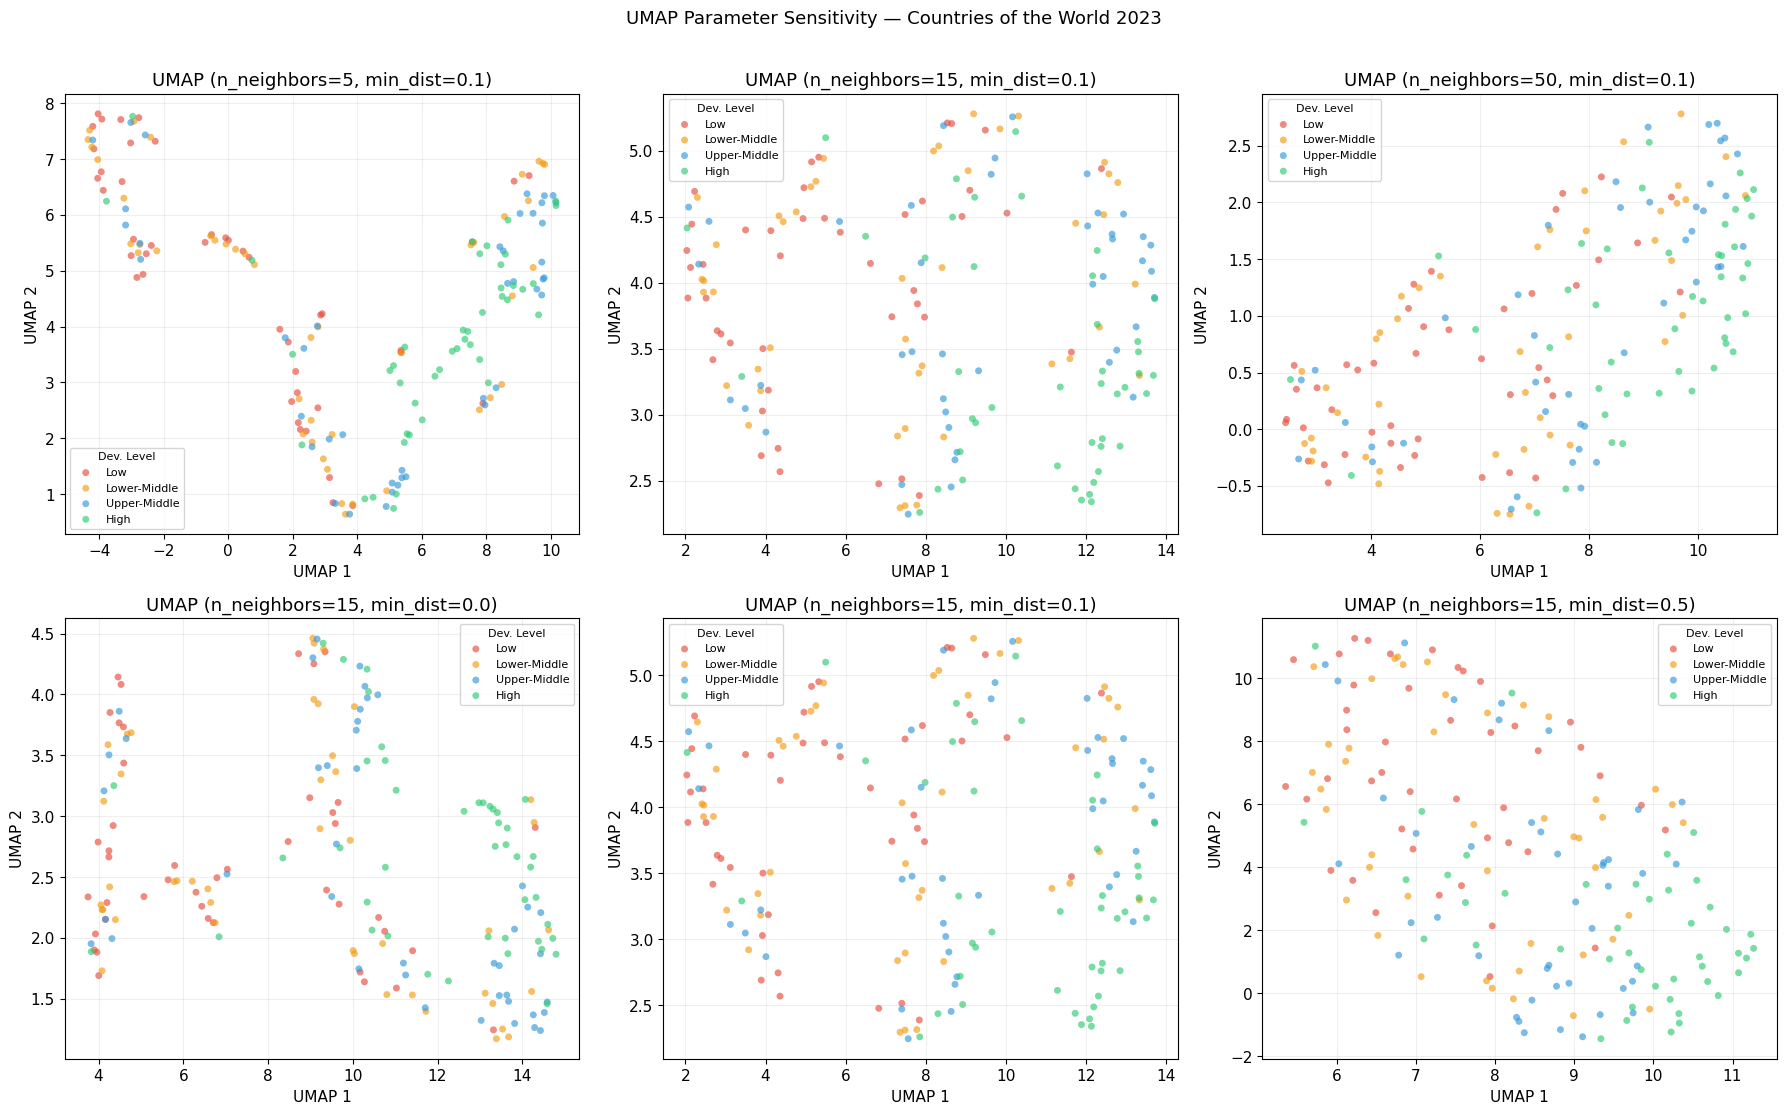


Observations (n_neighbors sweep, min_dist=0.1):
  n_neighbors=5  : fragmented, heavy emphasis on local structure.
  n_neighbors=15 : balanced; development clusters clearly visible.
  n_neighbors=50 : smoother layout, more global structure preserved.

Observations (min_dist sweep, n_neighbors=15):
  min_dist=0.0 : extremely tight clusters, points nearly stacked.
  min_dist=0.1 : well-separated and legible clusters (recommended).
  min_dist=0.5 : more spread out; group boundaries become diffuse.


In [28]:
# =============================================================================
# ITEM 8: UMAP — n_neighbors and min_dist Sensitivity
# =============================================================================

if UMAP_AVAILABLE:
    print("=" * 70)
    print("UMAP: EXPLORING PARAMETER SENSITIVITY")
    print("=" * 70)
    print()
    print("UMAP key parameters:")
    print("  n_neighbors : local vs. global tradeoff (low = local, high = global)")
    print("  min_dist    : how tightly to pack points in 2D (low = tight clusters)")
    print("  random_state: always set for reproducibility")
    print()

    # Row 1: vary n_neighbors (min_dist fixed at 0.1)
    neighbor_values = [5, 15, 50]
    umap_nbr = {}
    for n in neighbor_values:
        print(f"  Fitting UMAP n_neighbors={n}, min_dist=0.1...", end=" ")
        reducer = umap.UMAP(n_components=2, n_neighbors=n, min_dist=0.1, random_state=42)
        umap_nbr[n] = reducer.fit_transform(X_scaled)
        print("done")

    # Row 2: vary min_dist (n_neighbors fixed at 15)
    min_dist_values = [0.0, 0.1, 0.5]
    umap_dist = {}
    for d in min_dist_values:
        print(f"  Fitting UMAP n_neighbors=15, min_dist={d}...", end=" ")
        reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=d, random_state=42)
        umap_dist[d] = reducer.fit_transform(X_scaled)
        print("done")

    # Plot 2 rows x 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))

    for j, n in enumerate(neighbor_values):
        Z  = umap_nbr[n]
        ax = axes[0, j]
        for level in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
            mask = (gdp_quartiles == level)
            ax.scatter(Z[mask, 0], Z[mask, 1],
                       c=dev_colors[level], label=level,
                       alpha=0.65, s=25, edgecolors='none')
        ax.set_title(f'UMAP (n_neighbors={n}, min_dist=0.1)')
        ax.set_xlabel('UMAP 1');  ax.set_ylabel('UMAP 2')
        ax.legend(title='Dev. Level', fontsize=8, title_fontsize=8)
        ax.grid(True, alpha=0.2)

    for j, d in enumerate(min_dist_values):
        Z  = umap_dist[d]
        ax = axes[1, j]
        for level in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
            mask = (gdp_quartiles == level)
            ax.scatter(Z[mask, 0], Z[mask, 1],
                       c=dev_colors[level], label=level,
                       alpha=0.65, s=25, edgecolors='none')
        ax.set_title(f'UMAP (n_neighbors=15, min_dist={d})')
        ax.set_xlabel('UMAP 1');  ax.set_ylabel('UMAP 2')
        ax.legend(title='Dev. Level', fontsize=8, title_fontsize=8)
        ax.grid(True, alpha=0.2)

    plt.suptitle('UMAP Parameter Sensitivity — Countries of the World 2023',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print()
    print("Observations (n_neighbors sweep, min_dist=0.1):")
    print("  n_neighbors=5  : fragmented, heavy emphasis on local structure.")
    print("  n_neighbors=15 : balanced; development clusters clearly visible.")
    print("  n_neighbors=50 : smoother layout, more global structure preserved.")
    print()
    print("Observations (min_dist sweep, n_neighbors=15):")
    print("  min_dist=0.0 : extremely tight clusters, points nearly stacked.")
    print("  min_dist=0.1 : well-separated and legible clusters (recommended).")
    print("  min_dist=0.5 : more spread out; group boundaries become diffuse.")

else:
    print("UMAP not available.")

`n_neighbors` controls how many nearby points each point looks at.

* Small value (5): focuses on very local structure. Clusters are tight but can break into small pieces.
* Large value (50): includes more distant points. Clusters become smoother and more connected.

`min_dist` controls how close points can be in the final plot.

* 0.0: points are packed very tightly, clusters look dense and hard to read.
* 0.5: points are more spread out, easier to see, but clusters become less clear.

In the results:

* Increasing `n_neighbors` made clusters more complete and less fragmented.
* Increasing `min_dist` spread points out, making countries easier to see, but made some groups harder to separate.

### #9
Take your best t-SNE result and your best UMAP result (n_neighbors=15, min_dist=0.1). Plot them side by side and label the 15 specified countries directly on each plot.

COUNTRY NAME CHECK
  Found   (14): ['United States', 'China', 'India', 'Brazil', 'Germany', 'Nigeria', 'Ethiopia', 'Japan', 'South Africa', 'Indonesia', 'Mexico', 'Bangladesh', 'Norway', 'Haiti']
  Missing (1): ['Russian Federation']



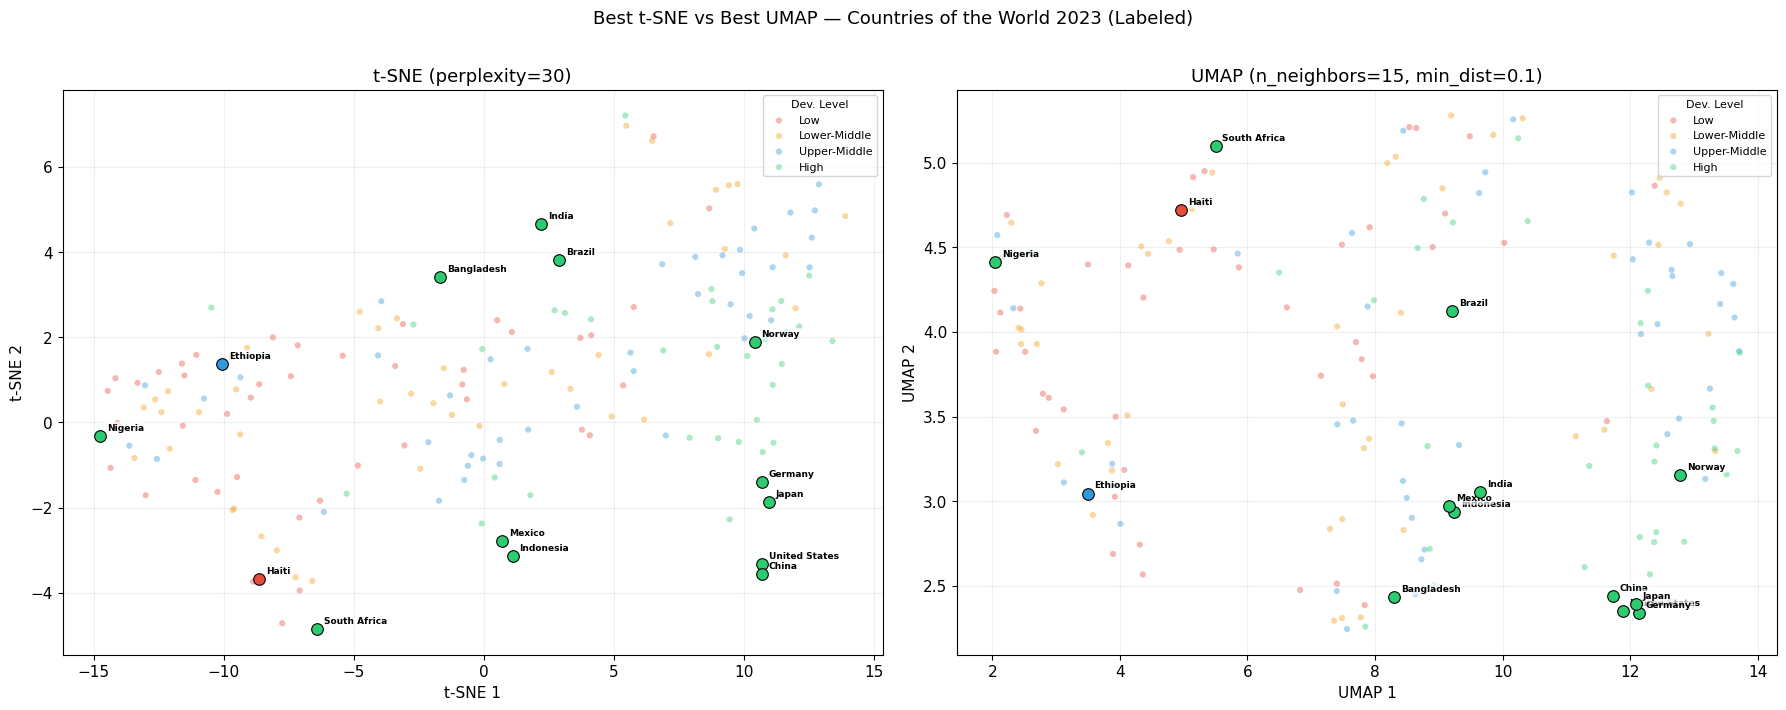

In [31]:
# =============================================================================
# ITEM 9: Best t-SNE vs Best UMAP — 15 Labeled Countries
# =============================================================================

target_countries = [
    'United States', 'China', 'India', 'Brazil', 'Germany',
    'Nigeria', 'Ethiopia', 'Japan', 'Russian Federation', 'South Africa',
    'Indonesia', 'Mexico', 'Bangladesh', 'Norway', 'Haiti'
]

country_list = list(countries)
found   = [c for c in target_countries if c in country_list]
missing = [c for c in target_countries if c not in country_list]

print("=" * 70)
print("COUNTRY NAME CHECK")
print("=" * 70)
print(f"  Found   ({len(found)}): {found}")
print(f"  Missing ({len(missing)}): {missing if missing else 'None'}")
print()

# Best t-SNE: perplexity=30
Z_tsne_best = tsne_results[30]

# Best UMAP: n_neighbors=15, min_dist=0.1
if UMAP_AVAILABLE:
    Z_umap_best = umap_dist[0.1]
    umap_title  = 'UMAP (n_neighbors=15, min_dist=0.1)'
    ux, uy      = 'UMAP 1', 'UMAP 2'
else:
    print("UMAP not available — using t-SNE perplexity=15 as substitute.")
    tsne_sub    = TSNE(n_components=2, perplexity=15, max_iter=1000,
                       random_state=42, learning_rate='auto', init='pca')
    Z_umap_best = tsne_sub.fit_transform(X_scaled)
    umap_title  = 't-SNE (perplexity=15) — UMAP substitute'
    ux, uy      = 't-SNE 1', 't-SNE 2'

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, Z, title, xlabel, ylabel in [
    (axes[0], Z_tsne_best, 't-SNE (perplexity=30)',  't-SNE 1', 't-SNE 2'),
    (axes[1], Z_umap_best, umap_title,                ux,        uy),
]:
    # Background scatter
    for level in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
        mask = (gdp_quartiles == level)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=dev_colors[level], label=level,
                   alpha=0.40, s=20, edgecolors='none')

    # Labeled target countries
    for c in found:
        idx = country_list.index(c)
        ax.scatter(Z[idx, 0], Z[idx, 1], s=70, zorder=5,
                   edgecolors='black', linewidths=0.8,
                   c=dev_colors[str(gdp_quartiles[idx])])
        ax.annotate(
            c, (Z[idx, 0], Z[idx, 1]),
            textcoords='offset points', xytext=(5, 4),
            fontsize=6.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, lw=0)
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel);  ax.set_ylabel(ylabel)
    ax.legend(title='Dev. Level', fontsize=8, title_fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('Best t-SNE vs Best UMAP — Countries of the World 2023 (Labeled)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Five countries and their placements:

1. **Norway**
   In the High development group, as expected. It clusters with other wealthy countries due to high life expectancy, low birth rate, and high GDP.

2. **Nigeria**
   In the Low development group. Its high birth rate and infant mortality explain this. It sits a bit apart from some low-income countries, likely because of its larger economy.

3. **China**
   In the Upper-Middle group. This makes sense given its GDP and urban population. It appears slightly higher than similar countries because of rapid urbanization and high CO₂ emissions.

4. **Haiti**
   Clearly in the Low development group. This is expected due to very low GDP and high infant mortality.

5. **Bangladesh**
   Near the Lower-Middle group but close to Low. This is interesting. Its health outcomes have improved a lot, so it sits between low-income and better-performing countries.

---
## Part 4 - Comparison and Recommendation

### #10
Plot PCA, t-SNE, and UMAP side by side in one figure, all colored by development level with the same legend. If UMAP is not available, use a second t-SNE at a different perplexity instead.

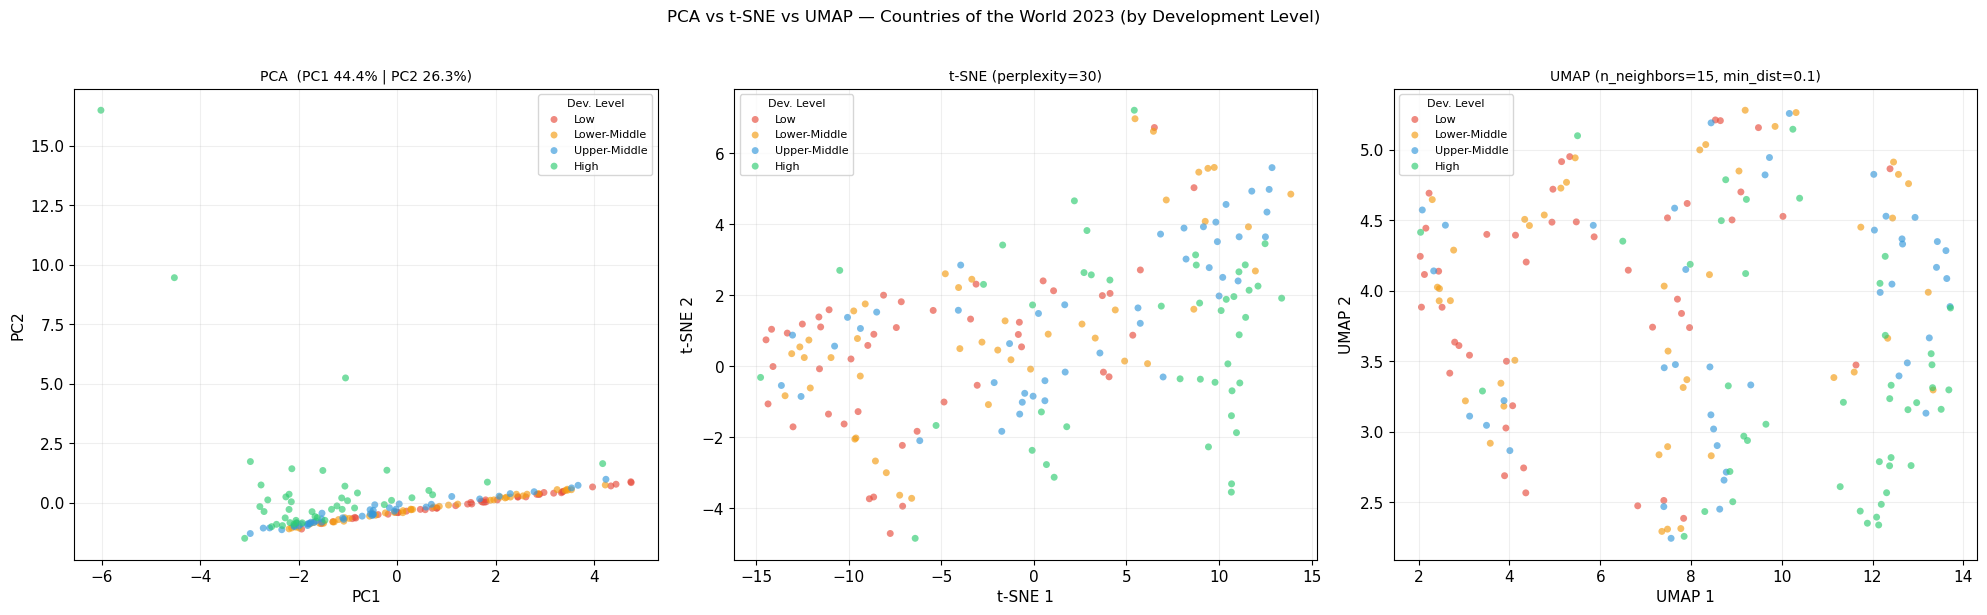

In [35]:
# =============================================================================
# ITEM 10: PCA vs t-SNE vs UMAP — Side-by-Side Comparison
# =============================================================================

if UMAP_AVAILABLE:
    Z_third     = umap_dist[0.1]
    third_title = 'UMAP (n_neighbors=15, min_dist=0.1)'
    third_x, third_y = 'UMAP 1', 'UMAP 2'
else:
    Z_third     = tsne_results[15]
    third_title = 't-SNE (perplexity=15) — UMAP substitute'
    third_x, third_y = 't-SNE 1', 't-SNE 2'

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plots = [
    (axes[0], X_pca_2d,
     f'PCA  (PC1 {pca_2d.explained_variance_ratio_[0]*100:.1f}% | PC2 {pca_2d.explained_variance_ratio_[1]*100:.1f}%)',
     'PC1', 'PC2'),
    (axes[1], tsne_results[30], 't-SNE (perplexity=30)', 't-SNE 1', 't-SNE 2'),
    (axes[2], Z_third,          third_title,              third_x,   third_y),
]

for ax, Z, title, xlabel, ylabel in plots:
    for level in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
        mask = (gdp_quartiles == level)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=dev_colors[level], label=level,
                   alpha=0.65, s=25, edgecolors='none')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel);  ax.set_ylabel(ylabel)
    ax.legend(title='Dev. Level', fontsize=8, title_fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('PCA vs t-SNE vs UMAP — Countries of the World 2023 (by Development Level)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Looking at the three plots:

**PCA** shows a smooth gradient. High and Low development are at opposite ends, with the middle groups in between. The axes have clear meaning, but some groups overlap because PCA cannot capture complex patterns.

**t-SNE (perplexity = 30)** shows the clearest clusters. The four groups are very well separated. However, the axes have no meaning, and distances between clusters cannot be trusted.

**UMAP** is in between. It shows clearer clusters than PCA and keeps more overall structure than t-SNE. Distances are somewhat meaningful.

Overall, **UMAP is the most useful** for future data. It can place new countries into the same map without retraining, which PCA biplots and t-SNE cannot easily do.

### #11
Recommendation for the policy analyst team.

#### 1. What method do you recommend and why?

I recommend **PCA (Principal Component Analysis)** as the main method. It fits the goals best because it is easy to explain, shows which factors matter, and works on new data later.

PCA creates clear axes. Each axis is made from the original indicators like GDP, life expectancy, and birth rate. This makes it easy to understand what drives the results. For example, PC1 clearly represents development level. High birth rate and infant mortality push countries one way, while high life expectancy and GDP push them the other way. This is easy to explain to non-technical users. t-SNE and UMAP do not have this clarity because their axes have no real meaning.

#### 2. What from your results supports this?

Two results support PCA.

First, the **PCA plot (Item 5)** shows a clear pattern. High-income countries group together, and low-income countries group on the opposite side. The middle groups fall between them. This matches real-world development levels and is easy to interpret.

Second, the **reconstruction error (Item 6)** shows that PCA with 2 components still keeps most of the important information. Only a few countries are poorly represented. These are unusual cases that do not follow normal patterns.

#### 3. What are the limitations of your choice?

PCA is limited because it is **linear**. It cannot fully capture complex or curved patterns in the data. This is why some overlap still appears between middle-income groups.

It is also affected by **outliers and skewed data**, even after scaling. Very extreme countries can still influence the results.

#### 4. What are the other methods still good for?

**t-SNE** is useful for exploration because it shows very clear clusters, even if they are not mathematically meaningful.

**UMAP** is useful for visualization and tracking changes over time. It can also map new countries into the same space without rebuilding the model.

Overall, PCA is best for explanation and reporting, while t-SNE and UMAP are better for visualization and exploration.